
# Gradient Descent: Linear & Logistic Regression from Scratch

This notebook is a teaching demo for a machine learning class. It builds
**linear regression** and **logistic regression** from scratch using only
NumPy, trains both with **batch gradient descent**, and visualizes:

- How the fitted line / decision boundary evolves during training
- The loss (cost) curve over iterations
- The **loss surface (contour plot)** with the gradient descent path drawn on top

> Open this in Google Colab (File → Upload notebook, or drag-and-drop the
> `.ipynb` file into https://colab.research.google.com) and just run all
> cells (Runtime → Run all). No installs needed beyond the standard Colab
> environment.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True



---
## Part 1 — Linear Regression

We'll fit a line $\hat{y} = \theta_0 + \theta_1 x$ to noisy data by minimizing
the **Mean Squared Error (MSE)**:

$$
J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} \left(\theta_0 + \theta_1 x^{(i)} - y^{(i)}\right)^2
$$

using the gradient descent update rule:

$$
\theta_j \leftarrow \theta_j - \alpha \frac{\partial J}{\partial \theta_j}
$$


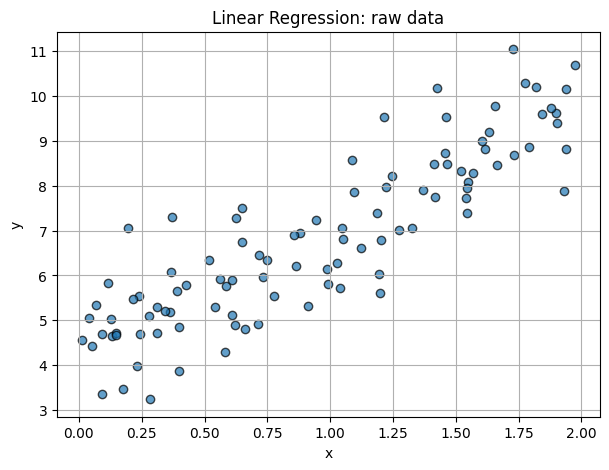

In [ ]:

# ---- 1.1 Generate synthetic data ----
m = 100
X = 2 * np.random.rand(m)                     # feature, shape (m,)
true_theta0, true_theta1 = 4.0, 3.0
y = true_theta0 + true_theta1 * X + np.random.randn(m) * 1.0  # add noise

plt.scatter(X, y, alpha=0.7, edgecolor='k')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression: raw data')
plt.show()


In [ ]:

# ---- 1.2 Cost function and gradients ----
def predict_linear(theta0, theta1, X):
    return theta0 + theta1 * X

def compute_cost_linear(theta0, theta1, X, y):
    m = len(X)
    preds = predict_linear(theta0, theta1, X)
    return np.sum((preds - y) ** 2) / (2 * m)

def compute_gradients_linear(theta0, theta1, X, y):
    m = len(X)
    preds = predict_linear(theta0, theta1, X)
    error = preds - y
    grad0 = np.sum(error) / m
    grad1 = np.sum(error * X) / m
    return grad0, grad1


In [ ]:

# ---- 1.3 Batch gradient descent ----
def gradient_descent_linear(X, y, theta0=0.0, theta1=0.0, lr=0.1, n_iters=100):
    history = {'theta0': [theta0], 'theta1': [theta1],
               'cost': [compute_cost_linear(theta0, theta1, X, y)]}
    for _ in range(n_iters):
        grad0, grad1 = compute_gradients_linear(theta0, theta1, X, y)
        theta0 -= lr * grad0
        theta1 -= lr * grad1
        history['theta0'].append(theta0)
        history['theta1'].append(theta1)
        history['cost'].append(compute_cost_linear(theta0, theta1, X, y))
    return theta0, theta1, history

theta0_final, theta1_final, hist_lin = gradient_descent_linear(
    X, y, theta0=0.0, theta1=0.0, lr=0.5, n_iters=60
)

print(f"Learned parameters: theta0 = {theta0_final:.3f}, theta1 = {theta1_final:.3f}")
print(f"True parameters:    theta0 = {true_theta0:.3f}, theta1 = {true_theta1:.3f}")


Learned parameters: theta0 = 4.210, theta1 = 2.774
True parameters:    theta0 = 4.000, theta1 = 3.000



### Visualization 1 — fitted line evolving over training


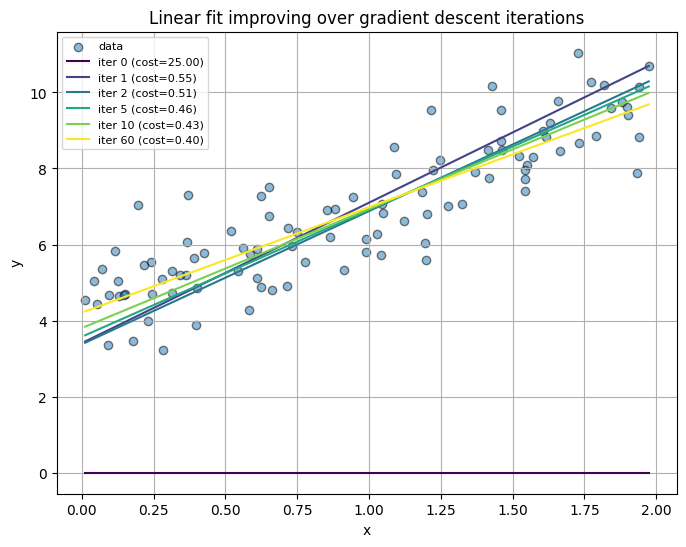

In [ ]:

snapshot_iters = [0, 1, 2, 5, 10, len(hist_lin['cost']) - 1]
x_line = np.linspace(X.min(), X.max(), 50)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.5, edgecolor='k', label='data', zorder=1)

cmap = plt.cm.viridis(np.linspace(0, 1, len(snapshot_iters)))
for c, it in zip(cmap, snapshot_iters):
    t0, t1 = hist_lin['theta0'][it], hist_lin['theta1'][it]
    plt.plot(x_line, predict_linear(t0, t1, x_line), color=c,
              label=f'iter {it} (cost={hist_lin["cost"][it]:.2f})')

plt.xlabel('x'); plt.ylabel('y')
plt.title('Linear fit improving over gradient descent iterations')
plt.legend(fontsize=8)
plt.show()



### Visualization 2 — loss (cost) vs iteration


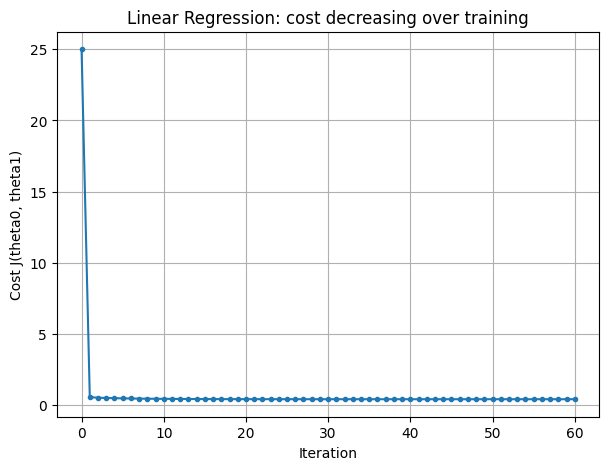

In [ ]:

plt.plot(hist_lin['cost'], marker='o', markersize=3)
plt.xlabel('Iteration')
plt.ylabel('Cost J(theta0, theta1)')
plt.title('Linear Regression: cost decreasing over training')
plt.show()



### Visualization 3 — loss contour with gradient descent path

We evaluate $J(\theta_0, \theta_1)$ on a grid around the trajectory and plot
contour lines, then overlay the path gradient descent actually took.


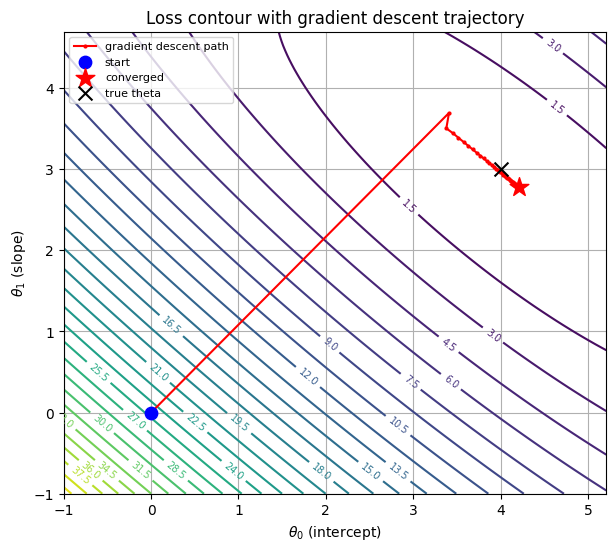

In [ ]:

theta0_vals = np.linspace(min(hist_lin['theta0']) - 1, max(hist_lin['theta0']) + 1, 100)
theta1_vals = np.linspace(min(hist_lin['theta1']) - 1, max(hist_lin['theta1']) + 1, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

J_vals = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        J_vals[i, j] = compute_cost_linear(T0[i, j], T1[i, j], X, y)

plt.figure(figsize=(7, 6))
cs = plt.contour(T0, T1, J_vals, levels=30, cmap='viridis')
plt.clabel(cs, inline=1, fontsize=7)

# gradient descent path
plt.plot(hist_lin['theta0'], hist_lin['theta1'], 'r.-', linewidth=1.5,
          markersize=4, label='gradient descent path')
plt.scatter([hist_lin['theta0'][0]], [hist_lin['theta1'][0]],
            color='blue', s=80, zorder=5, label='start')
plt.scatter([theta0_final], [theta1_final], color='red', marker='*',
            s=200, zorder=5, label='converged')
plt.scatter([true_theta0], [true_theta1], color='black', marker='x',
            s=100, zorder=5, label='true theta')

plt.xlabel(r'$\theta_0$ (intercept)')
plt.ylabel(r'$\theta_1$ (slope)')
plt.title('Loss contour with gradient descent trajectory')
plt.legend(fontsize=8)
plt.show()



---
## Part 2 — Logistic Regression

Now we classify points into two classes using the sigmoid function:

$$
\hat{y} = \sigma(w_1 x_1 + w_2 x_2), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}
$$

trained by minimizing **binary cross-entropy**:

$$
J(w_1, w_2) = -\frac{1}{m}\sum_{i=1}^m \left[y^{(i)} \log \hat{y}^{(i)} + (1-y^{(i)}) \log(1-\hat{y}^{(i)})\right]
$$

To keep the loss a clean function of just **two** weights (so we can draw a
2D contour plot), the data is generated with a decision boundary that passes
through the origin, so no bias term is needed.


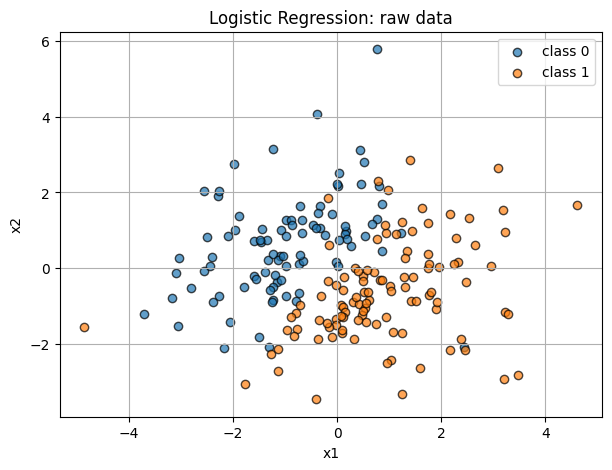

In [ ]:

# ---- 2.1 Generate synthetic classification data ----
m2 = 200
X_clf = np.random.randn(m2, 2) * 1.5

true_w1, true_w2 = 2.0, -1.5
logits = true_w1 * X_clf[:, 0] + true_w2 * X_clf[:, 1]
prob = 1 / (1 + np.exp(-logits))
y_clf = (prob > 0.5).astype(float)
# flip a few labels to add realistic noise
flip_idx = np.random.choice(m2, size=int(0.05 * m2), replace=False)
y_clf[flip_idx] = 1 - y_clf[flip_idx]

plt.scatter(X_clf[y_clf == 0, 0], X_clf[y_clf == 0, 1], label='class 0', alpha=0.7, edgecolor='k')
plt.scatter(X_clf[y_clf == 1, 0], X_clf[y_clf == 1, 1], label='class 1', alpha=0.7, edgecolor='k')
plt.xlabel('x1'); plt.ylabel('x2')
plt.title('Logistic Regression: raw data')
plt.legend()
plt.show()


In [ ]:

# ---- 2.2 Sigmoid, cost, gradients ----
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_logistic(w1, w2, X):
    z = w1 * X[:, 0] + w2 * X[:, 1]
    return sigmoid(z)

def compute_cost_logistic(w1, w2, X, y, eps=1e-12):
    m = len(y)
    preds = predict_logistic(w1, w2, X)
    preds = np.clip(preds, eps, 1 - eps)  # avoid log(0)
    return -np.sum(y * np.log(preds) + (1 - y) * np.log(1 - preds)) / m

def compute_gradients_logistic(w1, w2, X, y):
    m = len(y)
    preds = predict_logistic(w1, w2, X)
    error = preds - y
    grad_w1 = np.sum(error * X[:, 0]) / m
    grad_w2 = np.sum(error * X[:, 1]) / m
    return grad_w1, grad_w2


In [ ]:

# ---- 2.3 Batch gradient descent ----
def gradient_descent_logistic(X, y, w1=0.0, w2=0.0, lr=0.5, n_iters=100):
    history = {'w1': [w1], 'w2': [w2],
               'cost': [compute_cost_logistic(w1, w2, X, y)]}
    for _ in range(n_iters):
        g1, g2 = compute_gradients_logistic(w1, w2, X, y)
        w1 -= lr * g1
        w2 -= lr * g2
        history['w1'].append(w1)
        history['w2'].append(w2)
        history['cost'].append(compute_cost_logistic(w1, w2, X, y))
    return w1, w2, history

w1_final, w2_final, hist_log = gradient_descent_logistic(
    X_clf, y_clf, w1=0.0, w2=0.0, lr=0.9, n_iters=60
)

print(f"Learned weights: w1 = {w1_final:.3f}, w2 = {w2_final:.3f}")
print(f"True weights:    w1 = {true_w1:.3f}, w2 = {true_w2:.3f}")


Learned weights: w1 = 2.009, w2 = -1.496
True weights:    w1 = 2.000, w2 = -1.500



### Visualization 1 — decision boundary evolving over training

The decision boundary is where $w_1 x_1 + w_2 x_2 = 0$.


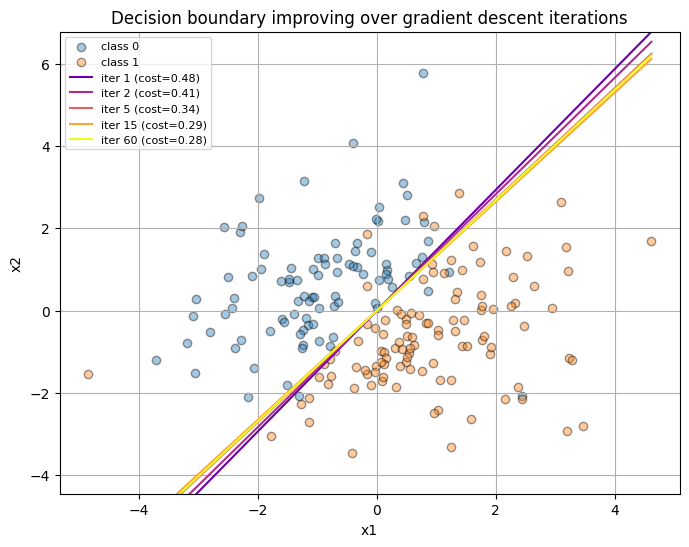

In [ ]:

snapshot_iters2 = [0, 1, 2, 5, 15, len(hist_log['cost']) - 1]
x1_line = np.linspace(X_clf[:, 0].min(), X_clf[:, 0].max(), 50)

plt.figure(figsize=(8, 6))
plt.scatter(X_clf[y_clf == 0, 0], X_clf[y_clf == 0, 1], label='class 0', alpha=0.4, edgecolor='k')
plt.scatter(X_clf[y_clf == 1, 0], X_clf[y_clf == 1, 1], label='class 1', alpha=0.4, edgecolor='k')

cmap2 = plt.cm.plasma(np.linspace(0, 1, len(snapshot_iters2)))
for c, it in zip(cmap2, snapshot_iters2):
    w1_i, w2_i = hist_log['w1'][it], hist_log['w2'][it]
    if abs(w2_i) > 1e-8:
        x2_line = -(w1_i * x1_line) / w2_i
        plt.plot(x1_line, x2_line, color=c,
                  label=f'iter {it} (cost={hist_log["cost"][it]:.2f})')

plt.xlabel('x1'); plt.ylabel('x2')
plt.ylim(X_clf[:, 1].min() - 1, X_clf[:, 1].max() + 1)
plt.title('Decision boundary improving over gradient descent iterations')
plt.legend(fontsize=8)
plt.show()



### Visualization 2 — loss (cost) vs iteration


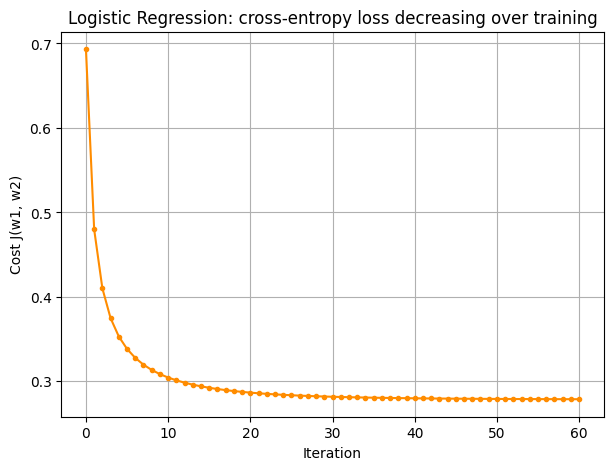

In [ ]:

plt.plot(hist_log['cost'], marker='o', markersize=3, color='darkorange')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w1, w2)')
plt.title('Logistic Regression: cross-entropy loss decreasing over training')
plt.show()



### Visualization 3 — loss contour with gradient descent path


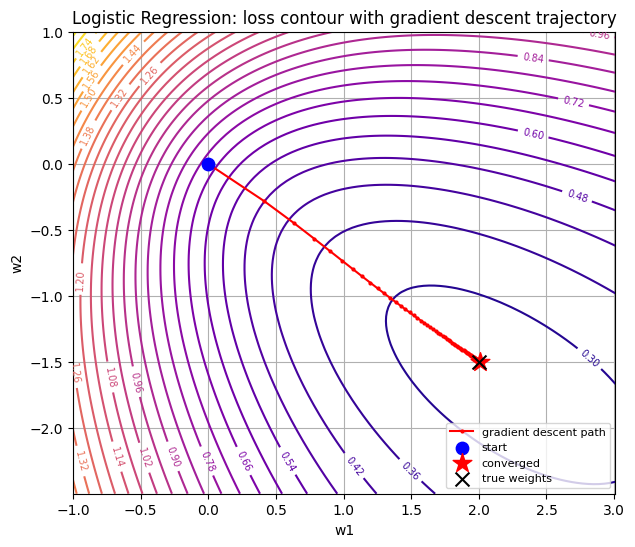

In [ ]:

w1_vals = np.linspace(min(hist_log['w1']) - 1, max(hist_log['w1']) + 1, 100)
w2_vals = np.linspace(min(hist_log['w2']) - 1, max(hist_log['w2']) + 1, 100)
W1, W2 = np.meshgrid(w1_vals, w2_vals)

J_vals2 = np.zeros_like(W1)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        J_vals2[i, j] = compute_cost_logistic(W1[i, j], W2[i, j], X_clf, y_clf)

plt.figure(figsize=(7, 6))
cs2 = plt.contour(W1, W2, J_vals2, levels=30, cmap='plasma')
plt.clabel(cs2, inline=1, fontsize=7)

plt.plot(hist_log['w1'], hist_log['w2'], 'r.-', linewidth=1.5,
          markersize=4, label='gradient descent path')
plt.scatter([hist_log['w1'][0]], [hist_log['w2'][0]],
            color='blue', s=80, zorder=5, label='start')
plt.scatter([w1_final], [w2_final], color='red', marker='*',
            s=200, zorder=5, label='converged')
plt.scatter([true_w1], [true_w2], color='black', marker='x',
            s=100, zorder=5, label='true weights')

plt.xlabel('w1')
plt.ylabel('w2')
plt.title('Logistic Regression: loss contour with gradient descent trajectory')
plt.legend(fontsize=8)
plt.show()



---
## Ideas for class discussion / exercises

1. **Learning rate sensitivity** — rerun Part 1 or Part 2 with a much larger
   `lr` (e.g. `2.0`) and a much smaller one (e.g. `0.01`). How does the path
   on the contour plot change? Does it overshoot, oscillate, or diverge?
2. **Feature scaling** — try generating `X` in Part 1 on a very different
   scale (e.g. `X * 1000`) and watch how elongated the contour ellipses
   become, and how that affects convergence speed.
3. **Stochastic / mini-batch gradient descent** — modify
   `gradient_descent_linear` / `gradient_descent_logistic` to update using a
   random subset of the data each step, and compare the (noisier) path on
   the contour plot to full-batch gradient descent.
4. **Regularization** — add an L2 penalty term to the cost and gradients and
   observe how the loss surface and the converged point shift.
